In [1]:
import numpy as np
from matplotlib import pyplot as plt
from scipy.integrate import solve_ivp

$
\left\{ \begin{array}{lcl}
\.x = \sigma(y - x) \\
\.y = x(\rho - z) - y \\
\.z = xy - \beta z
\end{array} \right.
$

$
\sigma = 10 \\
\beta = \frac{8}{3} \\
\rho = 38
$

In [2]:
# Parameters for Lorenz 1963 system
sigma = 10
beta = 8/3
rho = 38

In [ ]:
# RK4
def rk4_onestep(f, dt, t0, y0):
    f1 = f(t0, y0)
    f2 = f(t0 + dt/2, y0 + dt/2 * f1)
    f3 = f(t0 + dt/2, y0 + dt/2 * f2)
    f4 = f(t0 + dt, y0 + dt * f3)
    y_output = y0 + dt/6 * (f1 + 2*f2 + 2*f3 + f4)
    return y_output

In [4]:
# Lorenz in vector form
def Lorenz(t, y):
    dy = [sigma * (y[1] - y[0]),
          y[0] * (rho - y[2]) - y[1],
          y[0] * y[1] - beta * y[2]]
    return np.array(dy)

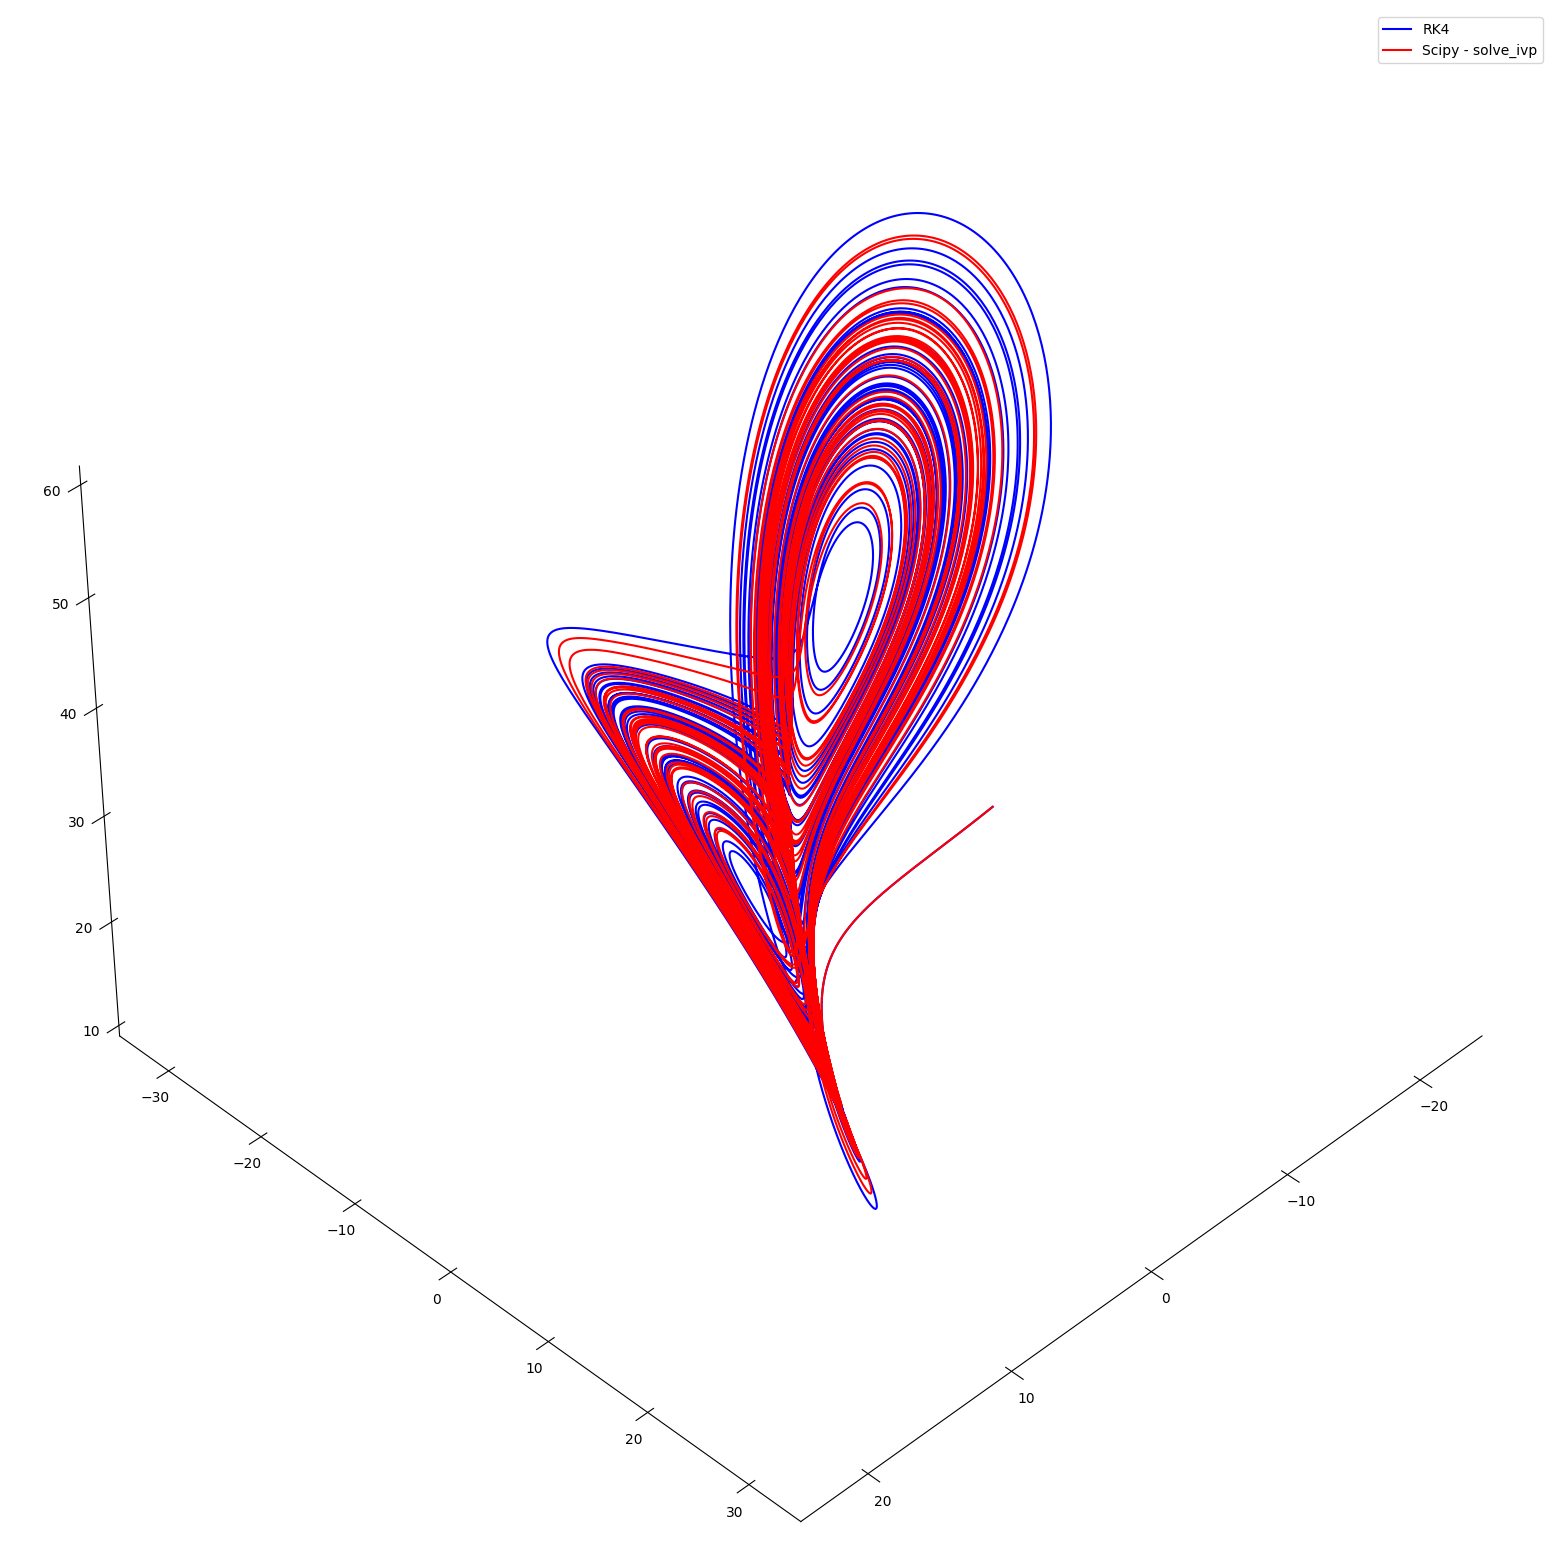

In [7]:
# Initial Condition
y0 = [-8, 8, 29]

# Trajectory
dt = 0.001
T = 50
num_time_pts = int(T/dt)
t = np.linspace(0, T, num_time_pts)

Y = np.zeros((3, num_time_pts)) # store the individual points derived by the scheme
Y[:, 0] = y0

y_init = y0
for i in range(num_time_pts - 1):
    y_next = rk4_onestep(Lorenz, dt, t[i], y_init)
    Y[:, i+1] = y_next
    y_init = y_next

fig = plt.figure(figsize=(20,20))
L = plt.axes(projection = '3d')
L.plot(Y[0, :], Y[1, :], Y[2, :], 'b', label = 'RK4')

Lorenz_solution = solve_ivp(Lorenz, (0,T), y0, t_eval=t)
t = Lorenz_solution.t
y = Lorenz_solution.y.T
L.plot(y[:, 0], y[:, 1], y[:, 2], 'r', label = 'Scipy - solve_ivp')

for axis in [L.xaxis.pane, L.yaxis.pane, L.zaxis.pane]:
    axis.fill = False
    axis.set_edgecolor('w')
L.grid(False)
L.view_init(elev=40, azim=45) 
L.legend()
plt.show()

